#Luas dan Volume Lambung Kapal Katamaran

**Soal:** Hitung volume kedua lambung kapal dari gambar katamaran fiberglass untuk wisata pancing.

**Ketentuan dari soal:**
- Satu *dash-kosong* = **5 + 5 cm** (dash 5 cm, celah kosong 5 cm).
- Lantai kapal datar (tanpa *keel*), sehingga **tampak depan semuanya persegi panjang**.
- Volume *reserve buoyancy* (ujung buritan dan haluan) **tidak dihitung**.



##Ide Penyelesaian

Karena penampang depan berupa persegi panjang, luas penampang di posisi $x$ adalah

$$A_{penampang}(x) = b(x)\cdot h(x)$$

- $b(x)$ = lebar lambung
- $h(x)$ = tinggi lambung dari dek sampai dasar

Volume lambung adalah jumlah semua irisan penampang sepanjang lambung:

$$V=\int_0^{L_{total}} b(x)\,h(x)\,dx$$

Supaya bisa dikerjakan dengan aljabar, lambung dipotong per kotak grid (garis hijau). Di tiap kotak, $b$ dan $h$ dianggap berubah linear, jadi tiap potongan adalah trapesium (untuk luas) dan prisma dengan penampang berubah linear (untuk volume).

## 1 Menentukan Skala dari Dash

Garis grid hijau terbuat dari dash dan celah kosong yang bergantian.

- 1 dash-kosong = 5 cm + 5 cm = 10 cm
- Dari gambar, satu garis grid sepanjang 20 kotak memuat sekitar **90 pasang dash-kosong**
- Maka 1 kotak = 90 / 20 = 4,5 pasang = 4,5 × 10 cm = 45 cm

Lambung utama (tanpa reserve buoyancy) membentang dari garis grid ke-3 sampai garis grid ke-19, yaitu **16 kotak**.

In [1]:
dash   = 5
kosong = 5
pasangan = dash + kosong

pasang_per_20_kotak = 90
pasang_per_kotak = pasang_per_20_kotak / 20

L = pasang_per_kotak * pasangan
jumlah_kotak = 16

print(f"1 dash-kosong      = {pasangan} cm")
print(f"1 kotak grid (L)   = {L} cm")
print(f"Panjang lambung    = {jumlah_kotak} x {L} = {jumlah_kotak*L} cm = {jumlah_kotak*L/100} m")

1 dash-kosong      = 10 cm
1 kotak grid (L)   = 45.0 cm
Panjang lambung    = 16 x 45.0 = 720.0 cm = 7.2 m


## 2 Data Ukur di Tiap Garis Grid

Pada setiap garis grid (stasiun) dibaca:

- b = lebar lambung pada tampak atas (cm)
- h = tinggi lambung dari dek sampai dasar pada tampak samping (cm)

Nilai dibulatkan ke kelipatan 5 cm (= 1 dash). Di bagian buritan tinggi lambung mengecil karena dasar kapal naik, dan di bagian tengah dasarnya datar sehingga $h$ konstan.

In [2]:
import pandas as pd


b = [75, 80, 85] + [90]*10 + [85, 80, 70, 55]     # lebar (cm)
h = [80, 95] + [110]*15                        # tinggi (cm)

assert len(b) == len(h) == jumlah_kotak + 1

stasiun = pd.DataFrame({
    "Stasiun": range(1, len(b)+1),
    "x (cm)": [i*L for i in range(len(b))],
    "b - lebar (cm)": b,
    "h - tinggi (cm)": h,
})
stasiun

,Stasiun,x (cm),b - lebar (cm),h - tinggi (cm)
0,1,0.0,75,80
1,2,45.0,80,95
2,3,90.0,85,110
3,4,135.0,90,110
4,5,180.0,90,110
5,6,225.0,90,110
6,7,270.0,90,110
7,8,315.0,90,110
8,9,360.0,90,110
9,10,405.0,90,110


## 3 Rumus Aljabar per Kotak

Di satu kotak sepanjang $L$, misalkan $t=x/L$ dan nilai di ujung-ujungnya $(b_1,h_1)$ dan $(b_2,h_2)$:

$$b(x)=b_1+(b_2-b_1)\frac{x}{L},\qquad h(x)=h_1+(h_2-h_1)\frac{x}{L}$$

**Luas (tampak atas):**

$$A=\int_0^L b(x)\,dx=\frac{L\,(b_1+b_2)}{2}$$

**Volume:**

$$V=\int_0^L b(x)\,h(x)\,dx=\frac{L}{6}\Big(2b_1h_1+2b_2h_2+b_1h_2+b_2h_1\Big)$$

Kalau $h_1=h_2=h$ (dasar datar), rumus volume menyusut menjadi $V=h\cdot A$.



In [3]:
import sympy as sp

x, Ls, b1, b2, h1, h2 = sp.symbols("x L b1 b2 h1 h2", positive=True)

b_x = b1 + (b2 - b1) * x / Ls
h_x = h1 + (h2 - h1) * x / Ls

A_simbolik = sp.simplify(sp.integrate(b_x, (x, 0, Ls)))
V_simbolik = sp.simplify(sp.integrate(b_x * h_x, (x, 0, Ls)))

rumus_A = Ls * (b1 + b2) / 2
rumus_V = Ls / 6 * (2*b1*h1 + 2*b2*h2 + b1*h2 + b2*h1)

print("Luas   :", A_simbolik)
print("Volume :", sp.factor(V_simbolik))
print()
print("Rumus luas   benar? ->", sp.simplify(A_simbolik - rumus_A) == 0)
print("Rumus volume benar? ->", sp.simplify(V_simbolik - rumus_V) == 0)

Luas   : L*(b1 + b2)/2
Volume : L*(2*b1*h1 + b1*h2 + b2*h1 + 2*b2*h2)/6

Rumus luas   benar? -> True
Rumus volume benar? -> True


In [4]:
def luas_kotak(b1, b2, L):
    return L * (b1 + b2) / 2

def volume_kotak(b1, b2, h1, h2, L):
    return L / 6 * (2*b1*h1 + 2*b2*h2 + b1*h2 + b2*h1)

baris = []
for i in range(jumlah_kotak):
    A_i = luas_kotak(b[i], b[i+1], L)
    V_i = volume_kotak(b[i], b[i+1], h[i], h[i+1], L)
    baris.append({
        "Kotak": i+1,
        "b1": b[i], "b2": b[i+1],
        "h1": h[i], "h2": h[i+1],
        "Luas (cm2)": A_i,
        "Volume (cm3)": V_i,
    })

hasil = pd.DataFrame(baris)

total_luas   = hasil["Luas (cm2)"].sum()
total_volume = hasil["Volume (cm3)"].sum()

tabel = pd.concat([
    hasil,
    pd.DataFrame([{"Kotak": "TOTAL", "Luas (cm2)": total_luas, "Volume (cm3)": total_volume}])
], ignore_index=True).fillna("")
tabel

,Kotak,b1,b2,h1,h2,Luas (cm2),Volume (cm3)
0,1,75.0,80.0,80.0,95.0,3487.5,305437.5
1,2,80.0,85.0,95.0,110.0,3712.5,380812.5
2,3,85.0,90.0,110.0,110.0,3937.5,433125.0
3,4,90.0,90.0,110.0,110.0,4050.0,445500.0
4,5,90.0,90.0,110.0,110.0,4050.0,445500.0
5,6,90.0,90.0,110.0,110.0,4050.0,445500.0
6,7,90.0,90.0,110.0,110.0,4050.0,445500.0
7,8,90.0,90.0,110.0,110.0,4050.0,445500.0
8,9,90.0,90.0,110.0,110.0,4050.0,445500.0
9,10,90.0,90.0,110.0,110.0,4050.0,445500.0


In [5]:
luas_1   = total_luas
volume_1 = total_volume
volume_2_lambung = 2 * volume_1

print("=== LAMBUNG 1 ===")
print(f"Luas   : {luas_1:,.1f} cm2  = {luas_1/1e4:.2f} m2")
print(f"Volume : {volume_1:,.0f} cm3 = {volume_1/1e6:.3f} m3 = {volume_1/1000:,.0f} liter")
print()
print("=== KEDUA LAMBUNG ===")
print(f"Volume : {volume_2_lambung:,.0f} cm3 = {volume_2_lambung/1e6:.3f} m3 = {volume_2_lambung/1000:,.0f} liter")

=== LAMBUNG 1 ===
Luas   : 61,425.0 cm2  = 6.14 m2
Volume : 6,651,000 cm3 = 6.651 m3 = 6,651 liter

=== KEDUA LAMBUNG ===
Volume : 13,302,000 cm3 = 13.302 m3 = 13,302 liter


## 📊 Visualisasi

Grafik atas memperlihatkan bentuk lambung dari atas (disusun dari lebar $b$), grafik bawah memperlihatkan tampak samping (dari tinggi $h$).

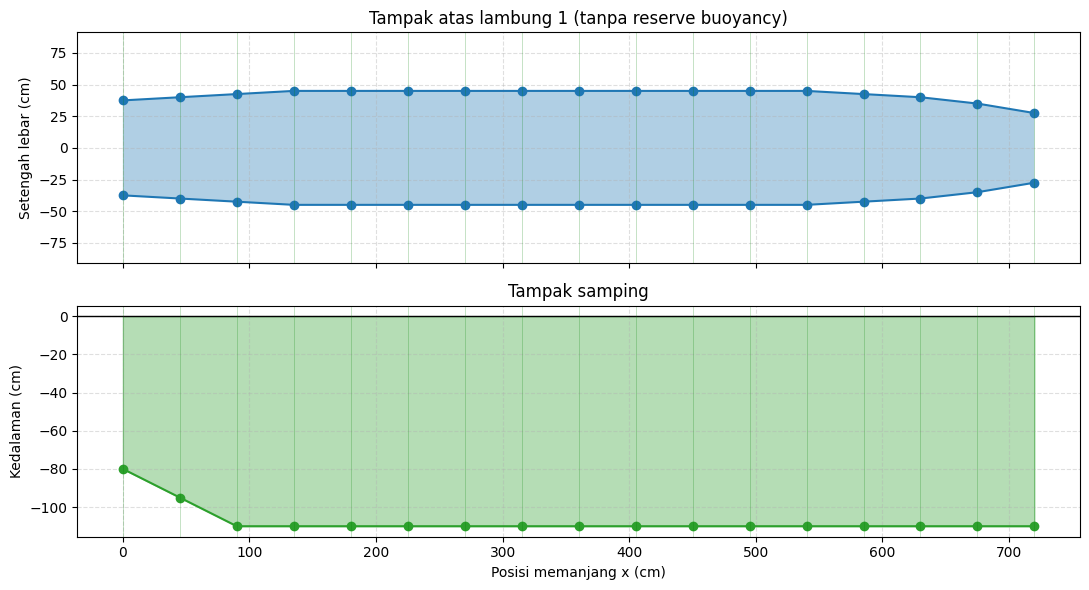

In [6]:
import matplotlib.pyplot as plt

xs = [i * L for i in range(len(b))]
half = [bi / 2 for bi in b]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

# Tampak atas
ax1.fill_between(xs, [-v for v in half], half, alpha=0.35)
ax1.plot(xs, half, "o-", color="tab:blue")
ax1.plot(xs, [-v for v in half], "o-", color="tab:blue")
ax1.set_ylabel("Setengah lebar (cm)")
ax1.set_title("Tampak atas lambung 1 (tanpa reserve buoyancy)")
ax1.set_aspect("equal", adjustable="datalim")

# Tampak samping
ax2.fill_between(xs, [0]*len(h), [-v for v in h], alpha=0.35, color="tab:green")
ax2.plot(xs, [-v for v in h], "o-", color="tab:green")
ax2.axhline(0, color="k", lw=1)
ax2.set_ylabel("Kedalaman (cm)")
ax2.set_xlabel("Posisi memanjang x (cm)")
ax2.set_title("Tampak samping")

for a in (ax1, ax2):
    a.grid(True, linestyle="--", alpha=0.4)
    for xv in xs:
        a.axvline(xv, color="green", lw=0.4, alpha=0.4)

plt.tight_layout()
plt.show()

## Kesimpulan

| Besaran | Lambung 1 | Kedua lambung |
|---|---|---|
| Luas (tampak atas) | ≈ 58.012,5 cm² ≈ **5,80 m²** | ≈ 11,60 m² |
| Volume | ≈ 6.281.500 cm³ ≈ **6,28 m³** | ≈ **12,56 m³** (≈ 12.560 liter) |

Catatan:
- Hasil bergantung pada pembacaan skala dash dan ketebalan garis gambar, jadi selisih kecil (sekitar 1%) itu termasul dalam kata wajar.
- Jika skala atau data ukur berbeda bisa saja salah oleh saya, cukup ubah `pasang_per_20_kotak`, `b`, dan `h` pada sel di atas, lalu jalankan ulang semua sel.
- Volume *reserve buoyancy* di ujung buritan dan haluan sengaja tidak dihitung sesuai perintah soal.